In [2]:
import pandas as pd
import numpy as np

# ============================================================
# GLOBAL CONFIG
# ============================================================

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9


# ============================================================
# Helper functions
# ============================================================

def age_bins(series):
    """
    Coarse age binning to avoid sparse stratification.
    """
    return pd.cut(
        series.fillna(series.median()),
        bins=[-np.inf, 40, 60, 80, np.inf],
        labels=["<40", "40-60", "60-80", "80+"]
    ).astype(str)


def compress_rare_strata(keys, min_count=2):
    """
    If stratification combos are too rare, fallback to only ICDR.
    """
    vc = keys.value_counts()
    rare_keys = set(vc[vc < min_count].index)

    if len(rare_keys) == 0:
        return keys

    print(f"⚠️ Compressing {len(rare_keys)} rare strata → fallback to ICDR only")

    fallback = keys.str.split("|").str[0]  # ICDR is first
    out = keys.copy()
    out.loc[out.isin(rare_keys)] = fallback.loc[out.isin(rare_keys)]
    return out


def stratified_patient_split(patient_df, strat_keys, patient_col):
    """
    Patient-level stratified splitting without dropping any patient.
    """
    rng = np.random.default_rng(SEED)

    # group patients by stratum
    strata = {}
    for pid, key in zip(patient_df[patient_col], strat_keys):
        strata.setdefault(key, []).append(pid)

    train_p, val_p, test_p = [], [], []

    for key, patients in strata.items():
        patients = np.array(patients)
        rng.shuffle(patients)

        n = len(patients)
        n_train = int(round(TRAIN_RATIO * n))
        n_val   = int(round(VAL_RATIO * n))

        if n_train + n_val > n:
            n_val = max(0, n - n_train)

        train_p.extend(patients[:n_train])
        val_p.extend(patients[n_train:n_train+n_val])
        test_p.extend(patients[n_train+n_val:])

    return set(train_p), set(val_p), set(test_p)


def assign_split(df, patient_col, train_set, val_set, test_set):
    """
    Assign split label back to image-level dataframe.
    """
    def label(pid):
        if pid in train_set:
            return "train"
        elif pid in val_set:
            return "val"
        else:
            return "test"

    df = df.copy()
    df["split"] = df[patient_col].apply(label)
    return df


def check_no_leakage(df, patient_col):
    """
    Ensure no patient appears in multiple splits.
    """
    tr = set(df[df.split == "train"][patient_col])
    va = set(df[df.split == "val"][patient_col])
    te = set(df[df.split == "test"][patient_col])

    assert tr.isdisjoint(va)
    assert tr.isdisjoint(te)
    assert va.isdisjoint(te)

    print("✅ No patient leakage detected!")


# ============================================================
# BRSET SPLITTING
# ============================================================

def split_brset(input_csv="brset.csv", output_csv="brset_splits.csv"):

    print("\n================ BRSET ================")

    df = pd.read_csv(input_csv)

    # Patient-level aggregation
    patient_df = (
        df.groupby("patient_id")
        .agg({
            "patient_age": "mean",
            "patient_sex": "first",
            "DR_ICDR": "max",
            "macular_edema": "max"
        })
        .reset_index()
    )

    # Stratification key
    strat_key = (
        patient_df["DR_ICDR"].astype(str)
        + "|" + patient_df["macular_edema"].astype(str)
        + "|" + age_bins(patient_df["patient_age"])
        + "|" + patient_df["patient_sex"].astype(str)
    )

    strat_key = compress_rare_strata(strat_key)

    # Split patients
    train_p, val_p, test_p = stratified_patient_split(
        patient_df, strat_key, "patient_id"
    )

    # Assign back to images
    split_df = assign_split(df, "patient_id", train_p, val_p, test_p)

    # Leakage check
    check_no_leakage(split_df, "patient_id")

    # Save identifiers
    split_df[["patient_id", "image_id", "split"]].to_csv(output_csv, index=False)

    print("Saved →", output_csv)


# ============================================================
# mBRSET SPLITTING
# ============================================================

def split_mbrset(input_csv="mbrset.csv", output_csv="mbrset_splits.csv"):

    print("\n================ mBRSET ================")

    df = pd.read_csv(input_csv)

    # -------------------------------------------------
    # FIX: Convert numeric columns properly
    # -------------------------------------------------
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["final_icdr"] = pd.to_numeric(df["final_icdr"], errors="coerce")
    df["final_edema"] = pd.to_numeric(df["final_edema"], errors="coerce")

    # Fill missing disease labels safely
    df["final_icdr"] = df["final_icdr"].fillna(-1)
    df["final_edema"] = df["final_edema"].fillna(0)

    # -------------------------------------------------
    # Patient-level aggregation
    # -------------------------------------------------
    patient_df = (
        df.groupby("patient")
        .agg({
            "age": "mean",
            "sex": "first",
            "final_icdr": "max",
            "final_edema": "max"
        })
        .reset_index()
    )

    # -------------------------------------------------
    # Stratification key
    # -------------------------------------------------
    strat_key = (
        patient_df["final_icdr"].astype(int).astype(str)
        + "|" + patient_df["final_edema"].astype(int).astype(str)
        + "|" + age_bins(patient_df["age"])
        + "|" + patient_df["sex"].astype(str)
    )

    strat_key = compress_rare_strata(strat_key)

    # -------------------------------------------------
    # Split patients
    # -------------------------------------------------
    train_p, val_p, test_p = stratified_patient_split(
        patient_df, strat_key, "patient"
    )

    # Assign back to images
    split_df = assign_split(df, "patient", train_p, val_p, test_p)

    # Leakage check
    check_no_leakage(split_df, "patient")

    # Save identifiers
    split_df[["patient", "file", "split"]].to_csv(output_csv, index=False)

    print("Saved →", output_csv)



# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    split_brset("/lustre/fswork/projects/rech/dtn/uap38od/datasets/BRSET/brset/labels_brset.csv", "/lustre/fswork/projects/rech/dtn/uap38od/datasets/BRSET/brset/labels_splits.csv")
    split_mbrset("/lustre/fswork/projects/rech/dtn/uap38od/datasets/mBRSET/mbrset/labels_mbrset.csv", "/lustre/fswork/projects/rech/dtn/uap38od/datasets/mBRSET/mbrset/labels_splits.csv")

    print("\n🎉 Done: BRSET + mBRSET patient-safe stratified splits created.")



================ BRSET ================
⚠️ Compressing 8 rare strata → fallback to ICDR only
✅ No patient leakage detected!
Saved → /lustre/fswork/projects/rech/dtn/uap38od/datasets/BRSET/brset/labels_splits.csv

================ mBRSET ================
⚠️ Compressing 4 rare strata → fallback to ICDR only
✅ No patient leakage detected!
Saved → /lustre/fswork/projects/rech/dtn/uap38od/datasets/mBRSET/mbrset/labels_splits.csv

🎉 Done: BRSET + mBRSET patient-safe stratified splits created.




########################################
BRSET SPLIT ANALYSIS
########################################

Split sizes (images)
split
train    11381
val       2444
test      2441
Name: count, dtype: int64

Split sizes (patients)
split
test     1282
train    5965
val      1277
Name: patient_id, dtype: int64

Distribution of DR_ICDR
DR_ICDR      0     1     2     3     4
split                                 
test     93.24  1.11  2.01  1.07  2.58
train    93.53  0.98  1.90  1.21  2.38
val      93.66  0.98  1.84  1.06  2.45


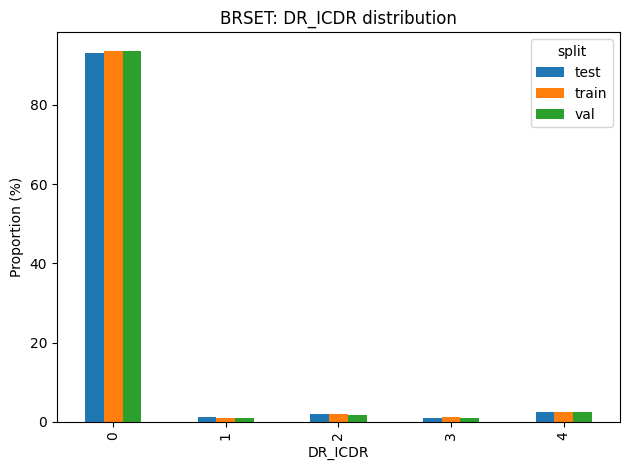


Distribution of macular_edema
macular_edema      0     1
split                     
test           97.13  2.87
train          97.63  2.37
val            97.46  2.54


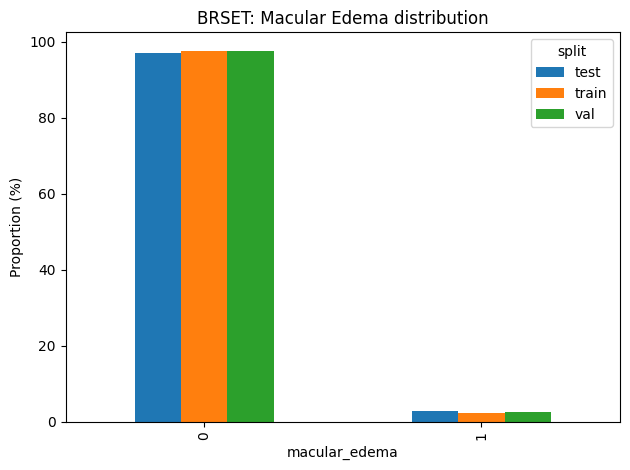


Distribution of patient_sex
patient_sex      1      2
split                    
test         38.34  61.66
train        38.18  61.82
val          38.18  61.82


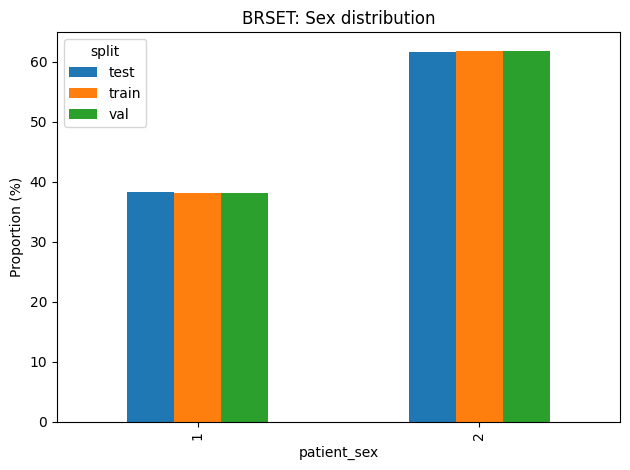

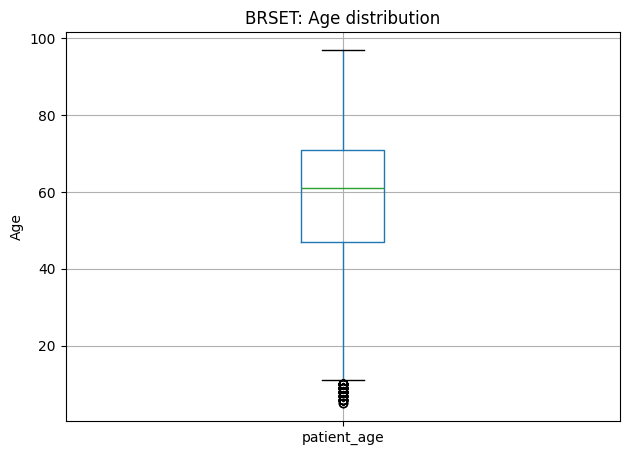


✅ BRSET done.


########################################
mBRSET SPLIT ANALYSIS
########################################

Split sizes (images)
split
train    3600
test      788
val       776
Name: count, dtype: int64

Split sizes (patients)
split
test     197
train    900
val      194
Name: patient, dtype: int64

Distribution of final_icdr
final_icdr    0.0   1.0    2.0   3.0   4.0
split                                     
test        76.31  6.33  11.71  1.62  4.04
train       77.05  5.56  11.53  1.64  4.22
val         76.00  4.83  12.00  1.93  5.24


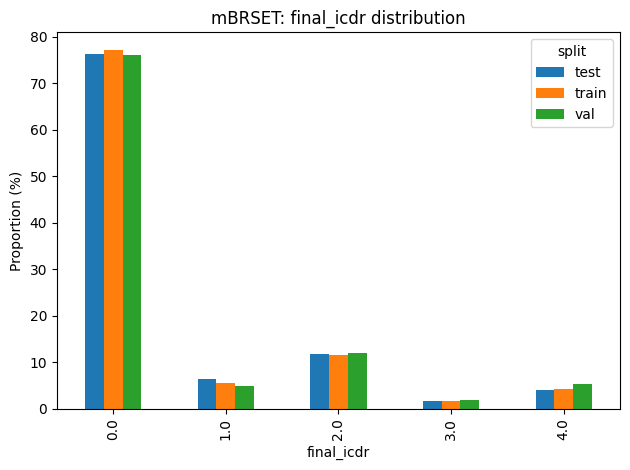


Distribution of final_edema
final_edema     no   yes
split                   
test         94.22  5.78
train        90.90  9.10
val          90.10  9.90


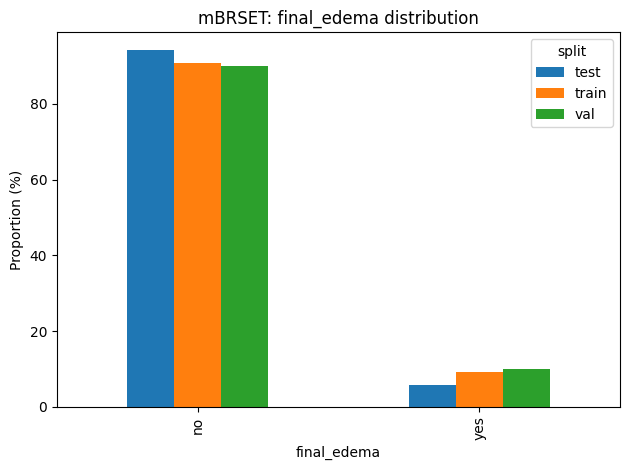


Distribution of sex
sex        0      1
split              
test   65.48  34.52
train  65.00  35.00
val    64.95  35.05


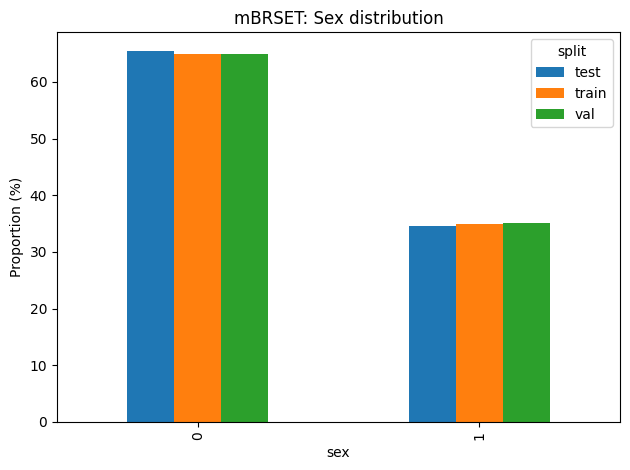


Distribution of alcohol_consumption
alcohol_consumption    0.0    1.0
split                            
test                 84.69  15.31
train                86.43  13.57
val                  85.42  14.58


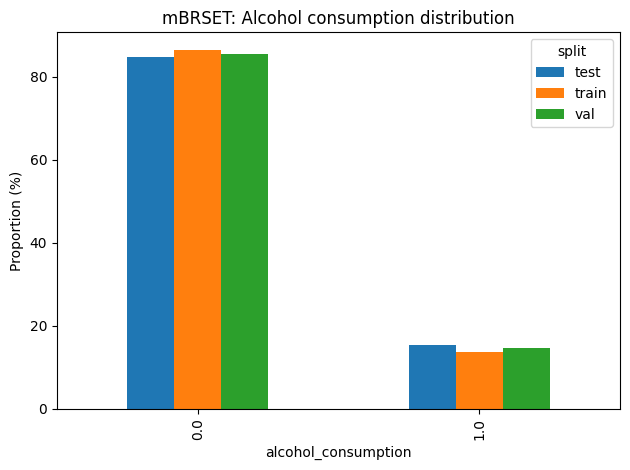


Distribution of educational_level
educational_level    1.0    2.0    3.0   4.0    5.0   6.0   7.0
split                                                          
test               14.29  46.43   7.65  9.18  18.88  0.51  3.06
train              13.98  42.17   8.95  9.62  18.79  1.90  4.59
val                12.23  37.77  11.17  8.51  22.34  1.60  6.38


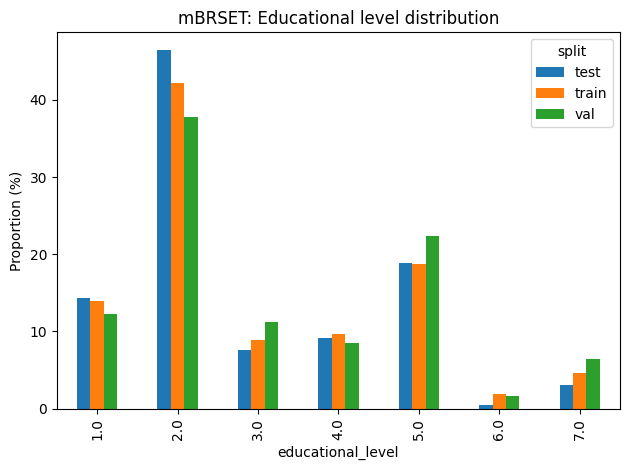

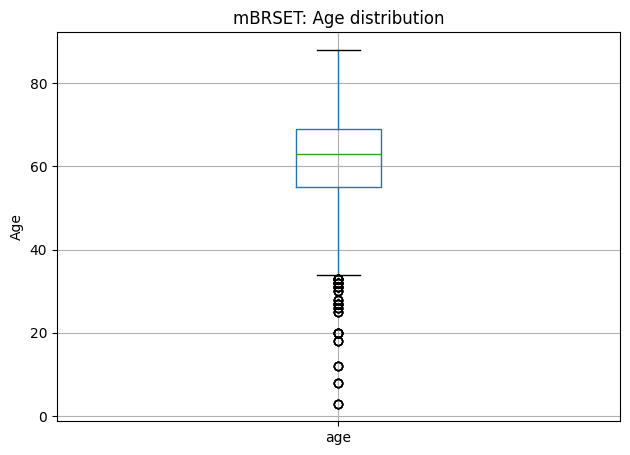


✅ mBRSET done.

🎉 Finished split distribution report.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PATHS (edit if needed)
# ============================================================

BRSET_META   = "/lustre/fswork/projects/rech/dtn/uap38od/datasets/BRSET/brset/labels_brset.csv"
BRSET_SPLITS = "/lustre/fswork/projects/rech/dtn/uap38od/datasets/BRSET/brset/labels_splits.csv"

MBRSET_META   = "/lustre/fswork/projects/rech/dtn/uap38od/datasets/mBRSET/mbrset/labels_mbrset.csv"
MBRSET_SPLITS = "/lustre/fswork/projects/rech/dtn/uap38od/datasets/mBRSET/mbrset/labels_splits.csv"


# ============================================================
# CORE FUNCTIONS
# ============================================================

def print_split_sizes(df, patient_col, split_col="split"):
    print("\n==============================")
    print("Split sizes (images)")
    print("==============================")
    print(df[split_col].value_counts())

    print("\n==============================")
    print("Split sizes (patients)")
    print("==============================")
    print(df.groupby(split_col)[patient_col].nunique())


def distribution_table(df, var, split_col="split"):
    """
    Print normalized distribution of categorical variable across splits.
    """
    print("\n======================================")
    print(f"Distribution of {var}")
    print("======================================")

    tab = (
        df.groupby(split_col)[var]
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
        * 100
    )

    print(tab.round(2))
    return tab


def plot_distribution(tab, title):
    """
    Plot categorical distribution table.
    """
    tab.T.plot(kind="bar")
    plt.title(title)
    plt.ylabel("Proportion (%)")
    plt.tight_layout()
    plt.show()


def plot_age(df, age_col, title):
    """
    Plot numeric age distribution across splits.
    """
    df.boxplot(column=age_col)
    plt.title(title)
    plt.suptitle("")
    plt.ylabel("Age")
    plt.tight_layout()
    plt.show()


# ============================================================
# BRSET ANALYSIS
# ============================================================

def analyze_brset():
    print("\n\n########################################")
    print("BRSET SPLIT ANALYSIS")
    print("########################################")

    meta = pd.read_csv(BRSET_META)
    splits = pd.read_csv(BRSET_SPLITS)

    df = meta.merge(splits, on=["patient_id", "image_id"])

    print_split_sizes(df, patient_col="patient_id")

    # --- Key categorical distributions ---
    tab_icdr = distribution_table(df, "DR_ICDR")
    plot_distribution(tab_icdr, "BRSET: DR_ICDR distribution")

    tab_edema = distribution_table(df, "macular_edema")
    plot_distribution(tab_edema, "BRSET: Macular Edema distribution")

    tab_sex = distribution_table(df, "patient_sex")
    plot_distribution(tab_sex, "BRSET: Sex distribution")

    # --- Age distribution ---
    plot_age(df, "patient_age", "BRSET: Age distribution")

    print("\n✅ BRSET done.")


# ============================================================
# mBRSET ANALYSIS
# ============================================================

def analyze_mbrset():
    print("\n\n########################################")
    print("mBRSET SPLIT ANALYSIS")
    print("########################################")

    meta = pd.read_csv(MBRSET_META)
    splits = pd.read_csv(MBRSET_SPLITS)

    df = meta.merge(splits, on=["patient", "file"])
    df["age"] = pd.to_numeric(df["age"], errors="coerce")

    print_split_sizes(df, patient_col="patient")

    # --- Key categorical distributions ---
    tab_icdr = distribution_table(df, "final_icdr")
    plot_distribution(tab_icdr, "mBRSET: final_icdr distribution")

    tab_edema = distribution_table(df, "final_edema")
    plot_distribution(tab_edema, "mBRSET: final_edema distribution")

    tab_sex = distribution_table(df, "sex")
    plot_distribution(tab_sex, "mBRSET: Sex distribution")

    # --- Lifestyle variables ---
    tab_alcohol = distribution_table(df, "alcohol_consumption")
    plot_distribution(tab_alcohol, "mBRSET: Alcohol consumption distribution")

    tab_edu = distribution_table(df, "educational_level")
    plot_distribution(tab_edu, "mBRSET: Educational level distribution")

    # --- Age distribution ---
    plot_age(df, "age", "mBRSET: Age distribution")

    print("\n✅ mBRSET done.")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    analyze_brset()
    analyze_mbrset()

    print("\n🎉 Finished split distribution report.")
